In [7]:
import sys
sys.path.append('/machfs/swhite/pyml/pyacal-test')
import pyacal
import os
import warnings
import at
import matplotlib.pyplot as plt
import time
import numpy
plt.rcParams['figure.figsize'] = [20, 10]
from pyacal.experiments.orbrespm import OrbRespm

In [8]:
pyacal.set_facility('esrf')
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    path = '/operation/beamdyn/matlab/optics/sr/theory/'
    ring = at.load_lattice('./betamodel.mat', use='betamodel')
pyacal.set_model('EBS', ring)

In [12]:
orbrespm = OrbRespm(accelerator='EBS', isonline=True)
orbrespm.params.delta_freq = 100   # [Hz]
orbrespm.params.delta_stren_hcm = 5.0e-5  # [rad]
orbrespm.params.delta_stren_vcm = 5.0e-5  # [rad]
orbrespm.params.sofb_nrpoints = 20
print(orbrespm.params)
print(f"Connected? {orbrespm.connected}")

delta_freq               =  1.00e+02  
delta_stren_hcm          =  1.00e-05  
delta_stren_vcm          =  1.00e-05  
sofb_nrpoints            =        20  

Connected? True


In [13]:
sofb = orbrespm.devices["sofb"]
# Select which CMs to measure
sofb.hcm_enbl[6:] = False
sofb.vcm_enbl[6:] = False

In [14]:
orbrespm._run()

Starting measurement at 2024-08-24 19h49m37s

001/192
19h49m37s --> Measuring OrbRespm for CH-SH1-C04-A

002/192
19h49m52s --> Measuring OrbRespm for CH-SH2-C04-B

003/192
19h50m05s --> Measuring OrbRespm for CH-SH3-C04-E

004/192
19h50m19s --> Measuring OrbRespm for CH-SH1-C05-A

005/192
19h50m32s --> Measuring OrbRespm for CH-SH2-C05-B

006/192
19h50m46s --> Measuring OrbRespm for CH-SH3-C05-E

007/192
     CM not enabled at SOFB. Skipping.

008/192
     CM not enabled at SOFB. Skipping.

009/192
     CM not enabled at SOFB. Skipping.

010/192
     CM not enabled at SOFB. Skipping.

011/192
     CM not enabled at SOFB. Skipping.

012/192
     CM not enabled at SOFB. Skipping.

013/192
     CM not enabled at SOFB. Skipping.

014/192
     CM not enabled at SOFB. Skipping.

015/192
     CM not enabled at SOFB. Skipping.

016/192
     CM not enabled at SOFB. Skipping.

017/192
     CM not enabled at SOFB. Skipping.

018/192
     CM not enabled at SOFB. Skipping.

019/192
     CM not enab

dict_keys(['timestamp', 'orbrespm', 'hcm_enbl', 'vcm_enbl', 'rfg_enbl'])
(640, 193)


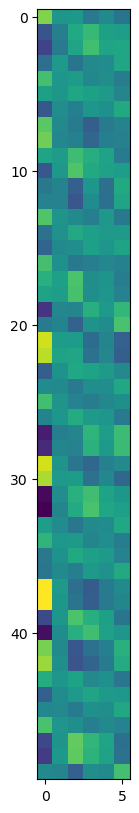

In [15]:
print(orbrespm.data.keys())
orm = orbrespm.data['orbrespm']
print(orm.shape)

plt.imshow(orm[:50, :6])

In [18]:
import pickle
with open('orm_sh2.pkl', 'wb') as f:
    pickle.dump(orbrespm.data, f)